# Task 3 — scPRINT-2 fine-tuning with differentiable batch MMD

This notebook exposes data loading, KNN preparation, fine-tuning, embedding, persistence, score validation, and UMAP review as separate steps.


## Protocol contract

The cell-type token is regularized across the groups defined by `batch_key`. Here `batch_key='orig.ident'`, so the groups are the two species. MMD is active with weight `0.03`; the user may replace the grouping key for another experiment.


In [1]:
import json
from pathlib import Path

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from scprint2.benchmark.task3 import (
    Task3Config,
    embed_task3,
    finetune_task3_checkpoint,
    load_task3_checkpoint,
    load_task3_dataset,
    prepare_task3_dataset,
    save_task3_embedding,
    seed_task3,
    summarize_task3_dataset,
    validate_task3_output_paths,
)
from scprint2.evaluation.task3_scib import (
    BATCH_METRICS,
    BIO_METRICS,
    Task3Scib113Config,
)

REPO_ROOT = next(
    path for path in [Path.cwd(), *Path.cwd().parents]
    if (path / "pyproject.toml").exists()
)
RUN_ROOT = REPO_ROOT / "data/results/cross_species_embedding/task3_fresh_ontology_knn_mmd003_20260815"
SCORES = RUN_ROOT / "task3_scib113_precomputed_scores.csv"
SCIB_METADATA = RUN_ROOT / "task3_scib113_precomputed_scores.metadata.json"
COMPLETE = RUN_ROOT / "task3_scib113_precomputed_scores.COMPLETE"
UMAP_ROOT = REPO_ROOT / "data/results/cross_species_embedding/task3_fresh_umaps_scoring_graph_20260818/plots"
UMAP_DATA = UMAP_ROOT / "task3_fresh_scored_embeddings_umaps.h5ad"
UMAP_METADATA = UMAP_ROOT / "task3_fresh_scored_embeddings_umaps.metadata.json"
RUN_FINETUNING = False


No module named 'adasplash'
FlashAttention is not installed, not using it..


## Artifact registry

Training, embedding, scoring, and visualization provenance are checked independently.


In [2]:
FT_METADATA = RUN_ROOT / "scprint2_ft_small_v2_mmd003_knn.metadata.json"
FT_COMPLETE = RUN_ROOT / "task3_scib113_precomputed_scores.COMPLETE"
artifact_registry = pd.DataFrame({
    "artifact": ["scores", "scIB metadata", "FT metadata", "completion marker", "UMAP coordinates", "UMAP metadata"],
    "path": [SCORES, SCIB_METADATA, FT_METADATA, FT_COMPLETE, UMAP_DATA, UMAP_METADATA],
})
artifact_registry["exists"] = artifact_registry["path"].map(Path.exists)
display(artifact_registry)
assert artifact_registry["exists"].all()


,artifact,path,exists
0,scores,/Users/jkobject/Documents/scPRINT/data/results...,True
1,scIB metadata,/Users/jkobject/Documents/scPRINT/data/results...,True
2,FT metadata,/Users/jkobject/Documents/scPRINT/data/results...,True
3,completion marker,/Users/jkobject/Documents/scPRINT/data/results...,True
4,UMAP coordinates,/Users/jkobject/Documents/scPRINT/data/results...,True
5,UMAP metadata,/Users/jkobject/Documents/scPRINT/data/results...,True


## Training data audit

The same 27,200 cells are used for the matched zero-shot and fine-tuned comparisons.


In [3]:
umap_data = ad.read_h5ad(UMAP_DATA)
audit_view = ad.AnnData(
    X=np.zeros((umap_data.n_obs, 0), dtype=np.float32),
    obs=umap_data.obs.rename(columns={"organism": "orig.ident"}).copy(),
)
audit_config = Task3Config(
    mode="scprint2-ft", input="task3.h5ad", checkpoint="small-v2.ckpt",
    output="ft.h5ad", notebook_provenance="fine_tuning_cross_species_emb_mmd.ipynb",
)
display(summarize_task3_dataset(audit_view, audit_config))
display(pd.crosstab(umap_data.obs["converted_cell_type_ontology"], umap_data.obs["organism"]))


cells                                  27200
genes                                      0
labels                                    14
batches                                    2
unknown_labels                          2947
batch_key                         orig.ident
label_key         cell_type_ontology_term_id
Name: Task3 dataset audit, dtype: object

organism,cat,tiger
converted_cell_type_ontology,,
Unknown,512,2435
ciliated cell,3345,0
club cell,0,1468
endothelial cell,553,1413
epithelial cell,2933,0
ionocyte,1171,0
macrophage,0,882
mesenchymal cell,0,3278
neuroendocrine cell,1199,0


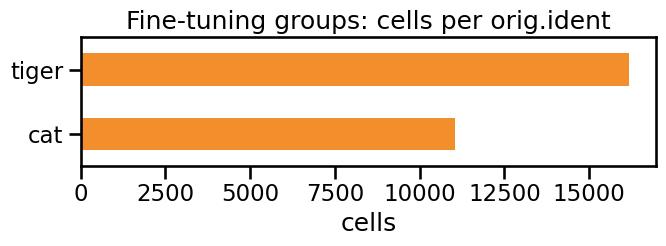

In [4]:
ax = umap_data.obs["organism"].value_counts().sort_values().plot.barh(
    figsize=(7, 2.8), color="#f28e2b"
)
ax.set_title("Fine-tuning groups: cells per orig.ident")
ax.set_xlabel("cells")
ax.set_ylabel("")
plt.tight_layout()


## MMD configuration

`batch_key` supplies the MMD groups; `do_mmd_on` selects the cell-type token being regularized. These are deliberately different concepts.


In [5]:
input_h5ad = REPO_ROOT / "notebooks/scPRINT-2-repro-notebooks/data/task_3_embed.h5ad"
checkpoint = Path("/path/to/small-v2.ckpt")
fresh_output = RUN_ROOT / "notebook_scprint2_ft_small_v2_mmd003_knn.h5ad"
finetune_config = Task3Config(
    mode="scprint2-ft", input=input_h5ad, checkpoint=checkpoint, output=fresh_output,
    notebook_provenance="Task3 FT differentiable MMD 0.03 cell-token KNN notebook",
    batch_key="orig.ident", cell_type_key="cell_type_ontology_term_id",
    finetune_max_len=2200, embed_max_len=2800, num_epochs=8,
    mmd_target="species", mmd_scale=0.03, include_organism_classification=True,
    use_knn=True, rebuild_knn_graph=True, include_unknown_train_labels=True, seed=42,
)
display(pd.Series(finetune_config.as_dict(), name="fine-tuning configuration"))


mode                                                                     scprint2-ft
input                              /Users/jkobject/Documents/scPRINT/notebooks/sc...
checkpoint                                                    /path/to/small-v2.ckpt
output                             /Users/jkobject/Documents/scPRINT/data/results...
notebook_provenance                Task3 FT differentiable MMD 0.03 cell-token KN...
batch_key                                                                 orig.ident
cell_type_key                                             cell_type_ontology_term_id
batch_size                                                                        32
num_workers                                                                        4
num_epochs                                                                         8
embed_how                                                                random expr
embed_max_len                                                    

## Optional fine-tuning

Each cell below performs one auditable operation. The checked-in execution reads the completed artifacts instead.


In [6]:
if RUN_FINETUNING:
    seed_task3(finetune_config.seed)
    reserved_paths = validate_task3_output_paths(finetune_config)
    display(pd.Series([str(path) for path in reserved_paths], name="reserved outputs"))


In [7]:
if RUN_FINETUNING:
    task3_data = load_task3_dataset(finetune_config)
    display(summarize_task3_dataset(task3_data, finetune_config))


In [8]:
if RUN_FINETUNING:
    task3_model = load_task3_checkpoint(finetune_config)
    print(type(task3_model).__name__)


In [9]:
if RUN_FINETUNING:
    task3_data, knn_graph_rebuilt = prepare_task3_dataset(
        task3_data, task3_model, finetune_config
    )
    display(pd.Series({"KNN graph rebuilt": knn_graph_rebuilt}, name="preparation"))


In [10]:
if RUN_FINETUNING:
    task3_model, training_filter, checkpoint_output = finetune_task3_checkpoint(
        task3_model, task3_data, finetune_config
    )
    display(pd.Series(training_filter, name="training result"))


In [11]:
if RUN_FINETUNING:
    task3_embedding = embed_task3(task3_model, task3_data, finetune_config)
    display(pd.Series({key: list(value.shape) for key, value in task3_embedding.obsm.items()}, name="obsm"))


In [12]:
if RUN_FINETUNING:
    embedding_artifacts = save_task3_embedding(
        task3_embedding, task3_data, finetune_config,
        training_filter=training_filter, knn_graph_rebuilt=knn_graph_rebuilt,
    )
    display(pd.Series(embedding_artifacts.as_dict(), name="saved artifacts"))


## Training provenance

The best validation epoch and loss, active losses, MMD groups, classification targets, and KNN status come from the saved fine-tuning metadata.


In [13]:
ft_metadata = json.loads(FT_METADATA.read_text())
ft_settings = ft_metadata["settings"]["finetune"]
training = ft_metadata["training_filter"]
display(pd.Series({
    "cells embedded": ft_metadata["cells"],
    "training cells": training["training_cells"],
    "epochs requested": ft_settings["num_epochs"],
    "best validation epoch": training["best_validation_epoch"],
    "best validation loss": training["best_validation_loss"],
    "MMD groups": ft_settings["mmd_batch_key"],
    "regularized token": ft_settings["do_mmd_on"],
    "MMD weight": ft_settings["loss_scalers"]["mmd"],
    "organism classification requested by locked rerun": True,
    "organism classification in historical metadata": ft_settings.get("organism_classification", "not recorded"),
    "KNN graph rebuilt": ft_metadata["settings"]["knn_graph_rebuilt"],
}, name="fine-tuning provenance"))


cells embedded                                                            27200
training cells                                                            27200
epochs requested                                                              8
best validation epoch                                                         2
best validation loss                                                   1.113448
MMD groups                                                           orig.ident
regularized token                                    cell_type_ontology_term_id
MMD weight                                                                 0.03
organism classification requested by locked rerun                          True
organism classification in historical metadata                     not recorded
KNN graph rebuilt                                                          True
Name: fine-tuning provenance, dtype: object

## Detailed scIB scores

The matched table keeps zero-shot and fine-tuned methods under the same legacy evaluator.


In [14]:
scib_metadata = json.loads(SCIB_METADATA.read_text())
assert scib_metadata["versions"]["scib"] == "1.1.3"
assert scib_metadata["total_formula"] == "0.4 * Batch correction + 0.6 * Bio conservation"
scores = pd.read_csv(SCORES).set_index("Method")
methods = ["scPRINT-2-ZS-cell-token-knn", "scPRINT-2-FT-cell-token-mmd003-knn"]
aggregate_columns = ["Batch correction", "Bio conservation", "Total"]
comparison = scores.loc[methods, aggregate_columns]
display(comparison)


,Batch correction,Bio conservation,Total
Method,,,
scPRINT-2-ZS-cell-token-knn,0.506897,0.602559,0.564294
scPRINT-2-FT-cell-token-mmd003-knn,0.524544,0.763302,0.667799


Method,scPRINT-2-ZS-cell-token-knn,scPRINT-2-FT-cell-token-mmd003-knn
ASW_label/batch,0.860078,8.090846e-01
PCR_batch,0.686476,8.404182e-01
graph_conn,0.929900,9.491392e-01
kBET,0.043230,2.407657e-02
iLISI,0.014799,2.220446e-16
NMI_cluster/label,0.573383,7.720446e-01
ARI_cluster/label,0.488054,7.145655e-01
ASW_label,0.511764,6.560941e-01
cLISI,0.950114,9.975709e-01
hvg_overlap,NaN,NaN


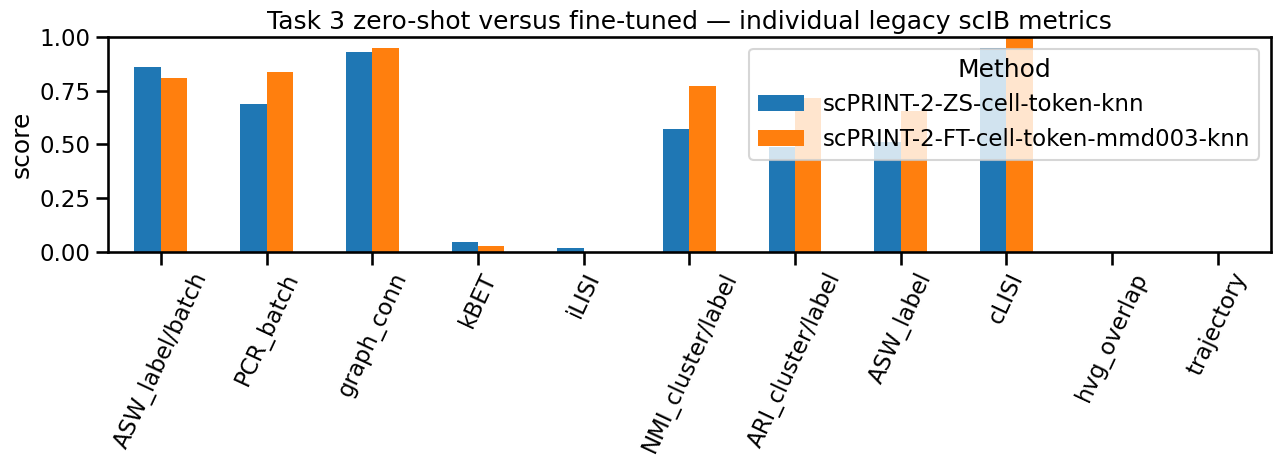

In [15]:
metric_comparison = scores.loc[methods, [*BATCH_METRICS, *BIO_METRICS]].T
display(metric_comparison)
ax = metric_comparison.plot.bar(figsize=(13, 5), ylim=(0, 1), rot=65)
ax.set_title("Task 3 zero-shot versus fine-tuned — individual legacy scIB metrics")
ax.set_ylabel("score")
plt.tight_layout()


,FT minus zero-shot
Batch correction,0.017647
Bio conservation,0.160743
Total,0.103505


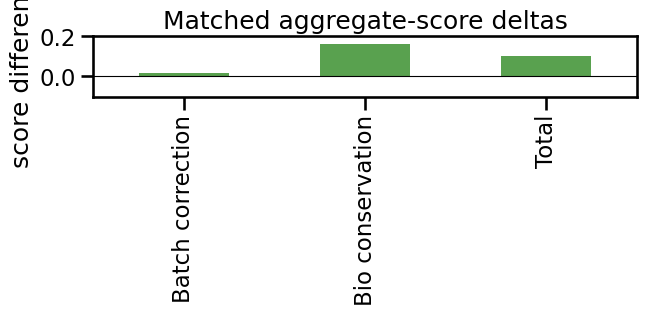

In [16]:
deltas = (comparison.loc[methods[1]] - comparison.loc[methods[0]]).rename("FT minus zero-shot")
display(deltas.to_frame())
colors = ["#59a14f" if value >= 0 else "#e15759" for value in deltas]
ax = deltas.plot.bar(figsize=(7, 3.5), color=colors, ylim=(-0.1, 0.2))
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Matched aggregate-score deltas")
ax.set_ylabel("score difference")
plt.tight_layout()


## UMAP diagnostics

The fine-tuned UMAP uses the scored cell-type-token embedding generated by the dedicated UMAP task; no neighbors are recomputed here.


![Task 3 UMAP overview](../../data/results/cross_species_embedding/task3_fresh_umaps_scoring_graph_20260818/plots/task3_fresh_scored_embeddings_umap_overview.png)


In [17]:
ft_umap_files = pd.Series({
    "organism": UMAP_ROOT / "scprint2_ft__organism.png",
    "ground truth": UMAP_ROOT / "scprint2_ft__converted_cell_type_ontology.png",
    "predicted cell type": UMAP_ROOT / "scprint2_ft__converted_predicted_cell_type_ontology.png",
}, name="fine-tuned UMAP files")
display(ft_umap_files.map(str).to_frame())
assert ft_umap_files.map(Path.exists).all()


,fine-tuned UMAP files
organism,/Users/jkobject/Documents/scPRINT/data/results...
ground truth,/Users/jkobject/Documents/scPRINT/data/results...
predicted cell type,/Users/jkobject/Documents/scPRINT/data/results...


### Fine-tuned organism, truth, and prediction panels

![Organism](../../data/results/cross_species_embedding/task3_fresh_umaps_scoring_graph_20260818/plots/scprint2_ft__organism.png)

![Ground truth](../../data/results/cross_species_embedding/task3_fresh_umaps_scoring_graph_20260818/plots/scprint2_ft__converted_cell_type_ontology.png)

![Prediction](../../data/results/cross_species_embedding/task3_fresh_umaps_scoring_graph_20260818/plots/scprint2_ft__converted_predicted_cell_type_ontology.png)


## Prediction concentration

This diagnostic compares how many ontology labels are used by the zero-shot and fine-tuned classifiers.


In [18]:
prediction_summary = pd.DataFrame({
    "zero-shot": umap_data.obs["scprint2_converted_predicted_cell_type_ontology"].value_counts(),
    "fine-tuned": umap_data.obs["scprint2_ft_converted_predicted_cell_type_ontology"].value_counts(),
}).fillna(0)
display(prediction_summary.sort_values("fine-tuned", ascending=False).head(20))
display(pd.Series({
    "zero-shot predicted labels": int((prediction_summary["zero-shot"] > 0).sum()),
    "fine-tuned predicted labels": int((prediction_summary["fine-tuned"] > 0).sum()),
}, name="prediction support"))


,zero-shot,fine-tuned
pulmonary alveolar type 2 cell,7657.0,7441.0
glomerular capillary endothelial cell,5933.0,4845.0
cardiac mesenchymal cell,1.0,3830.0
multiciliated epithelial cell of the bronchus,180.0,2570.0
pulmonary alveolar type 1 cell,896.0,2054.0
type EC enteroendocrine cell,1280.0,1815.0
club cell,420.0,1554.0
kidney proximal straight tubule epithelial cell,442.0,1093.0
metallothionein-positive alveolar macrophage,73.0,657.0
brain pericyte,1.0,560.0


zero-shot predicted labels     85
fine-tuned predicted labels    27
Name: prediction support, dtype: int64

## Interpretation boundary

The matched score difference bundles fine-tuning, MMD, organism classification, KNN input, and checkpoint selection. The historical metadata predates the explicit organism-classification field, so the locked rerun configuration is shown separately. This is not a single-factor MMD ablation.
